# Oversample Tuning

The fifth experiment focus on understanding the role of the oversample parameter.

As suggested : The regular-sampling step picks $P^2$ samples globally. Why not pick $P$ or $P^3$? What is the role of the *oversampling* factor?

The main focus is on the behavior based on the oversample factor. Here is reported the common configuration for all the experiments:

* **n_keys** : $5\times10^7$
* **n_ranks** : $8$
* **n_threads** : 8
* **keys_distribution** : uniform
* **merging_strategy** : binary

Experiments were executed on [**Orfeo, partition GENOA**](https://orfeo-doc.areasciencepark.it/HPC/computational-resources/).

The key metric here is **total_time_seconds**.

In [5]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

In [10]:
results = pd.read_csv("../Parallel/results/oversample_tuning.csv")
results = results[
    ["n_ranks", "oversample", "time_communication_seconds", "time_total_seconds"]
]
results.head()

,n_ranks,oversample,time_communication_seconds,time_total_seconds
0,8,1,0.135428,0.671026
1,8,2,0.099589,0.629340
2,8,4,0.073845,0.613625
3,8,8,0.068565,0.602866
4,8,16,0.063799,0.601275


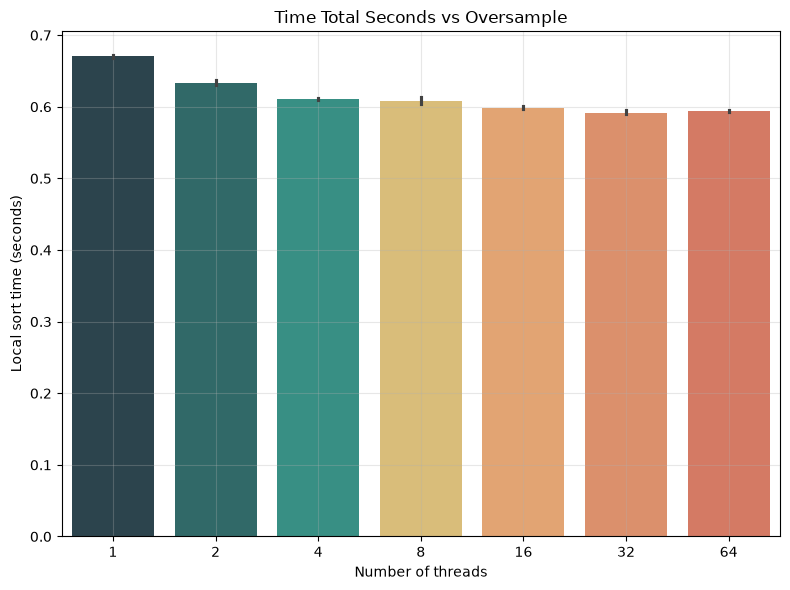

In [13]:
plot_data = results[ results["n_ranks"] == 8]

custom_palette = {
    1: "#264653",
    2: "#287271",
    4: "#2a9d8f",
    8: "#e9c46a",
    16: "#f4a261",
    32: "#ee8959",
    64: "#e76f51",
}


plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x="oversample",
    y="time_total_seconds",
    hue="oversample",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Number of threads")
plt.ylabel("Local sort time (seconds)")
plt.title(f"Time Total Seconds vs Oversample")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

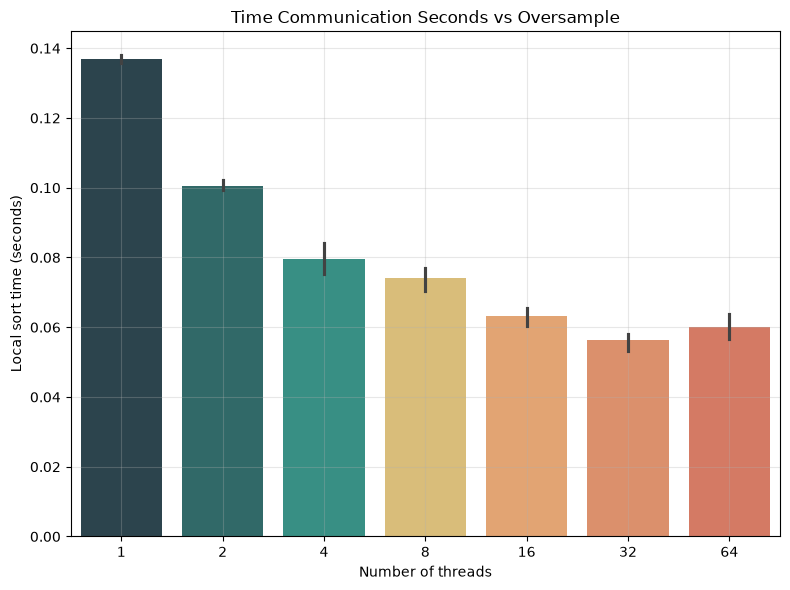

In [ ]:
custom_palette = {
    1: "#264653",
    2: "#287271",
    4: "#2a9d8f",
    8: "#e9c46a",
    16: "#f4a261",
    32: "#ee8959",
    64: "#e76f51",
}


plt.figure(figsize=(8, 6))

sns.barplot(
    data=plot_data,
    x="oversample",
    y="time_communication_seconds",
    hue="oversample",
    palette=custom_palette,
    legend=False
)

plt.xlabel("Number of threads")
plt.ylabel("Local sort time (seconds)")
plt.title(f"Time Communication Seconds vs Oversample")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()